# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install --upgrade gdown
# Скачиваем файл по ID
#file_id = '1GbwrOMykQa0YJ7EXFXZxFUVIj2OFjl2c'
#url = f'https://google.com{file_id}'
#url = "https://drive.google.com/file/d/1GbwrOMykQa0YJ7EXFXZxFUVIj2OFjl2c/view?usp=drive_link"
#!gdown {url}

# Распаковываем архив (название файла из ссылки обычно dataset.zip)
# Замените 'dataset.zip', если файл называется иначе после скачивания
#!unzip -q dataset.zip -d ./my_data



## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


Dataset ImageFolder
    Number of datapoints: 4720
    Root location: ./my_data/dataset/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.511, 0.488, 0.464], std=[0.343, 0.321, 0.322])
           )
Dataset ImageFolder
    Number of datapoints: 1088
    Root location: ./my_data/dataset/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.511, 0.488, 0.464], std=[0.343, 0.321, 0.322])
           )
Number of samples: 4720
Number of features: torch.Size([3, 224, 224])
Example data:


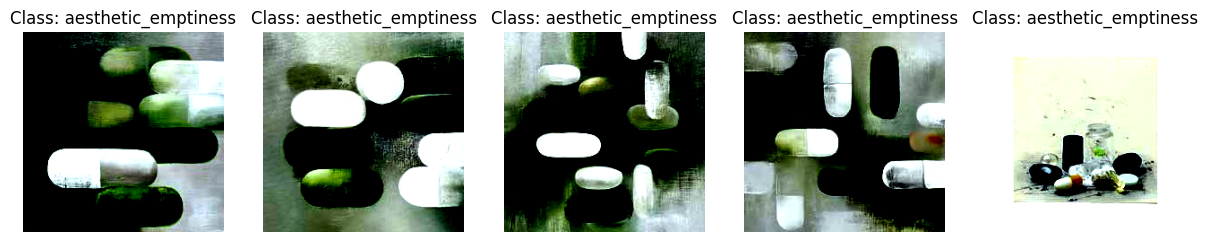

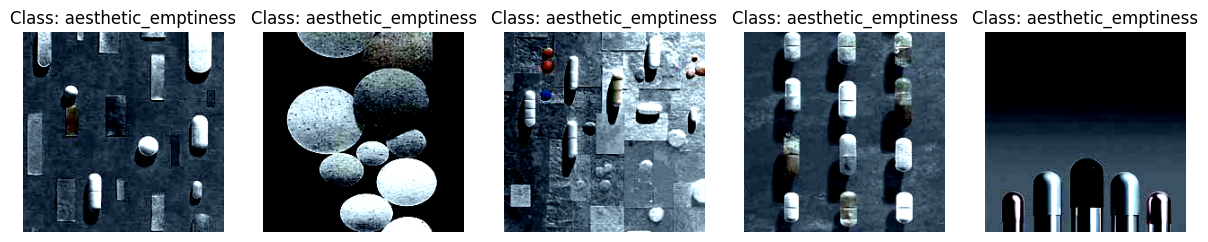

In [11]:
import pandas as pd
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from google.colab import drive

import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, num_images=5):
    plt.figure(figsize=(15, 5))

    for i in range(num_images):
        # Получаем картинку и индекс класса
        image, label = dataset[i]

        # Переводим тензор обратно в формат для отрисовки (H, W, C)
        # Изначально в PyTorch: (C, H, W)
        image = image.numpy().transpose((1, 2, 0))

        # Денормализация, если вы добавляли Normalize в transform (здесь не нужно)
        image = np.clip(image, 0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"Class: {dataset.classes[label]}")
        plt.axis('off')
    plt.show()

#!pip install --upgrade gdown


# https://learn.deeplearning.ai/specializations/pytorch-for-deep-learning-professional-certificate/lesson/bvvjkv/introduction-to-data-pipelines
# video with images


# Скачиваем файл по ID
#file_id = '1GbwrOMykQa0YJ7EXFXZxFUVIj2OFjl2c'
#url = f'https://google.com{file_id}'
#url = "https://drive.google.com/file/d/1GbwrOMykQa0YJ7EXFXZxFUVIj2OFjl2c/view?usp=drive_link"
#!gdown {url}

# Распаковываем архив (название файла из ссылки обычно dataset.zip)
# Замените 'dataset.zip', если файл называется иначе после скачивания
#!unzip -q dataset.zip -d ./my_data

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
#df = pd.read_csv('your_dataset.csv')
#df = pd.DataFrame(columns=['col1', 'col2', 'col3'])

#mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)


# 2. Указываем путь к КОРНЕВОЙ папке датасета
# Важно: ImageFolder ожидает, что внутри указанного пути лежат папки с классами.
# Если 'aesthetic_emptiness' — это один из классов, указывайте путь до папки 'test'

#mean: [0.5111283659934998, 0.48830345273017883, 0.46479079127311707],
#std: [0.3433663249015808, 0.3207928538322449, 0.32255250215530396]

transform = transforms.Compose([
    transforms.Resize((224, 224)), # Укажите нужный вам размер
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.511, 0.488, 0.464],
                         std=[0.343, 0.321, 0.322])
])

data_path = './my_data/dataset'



my_dataset_train = torchvision.datasets.ImageFolder(root=f"{data_path}/train" , transform=transform)
my_dataset_test = torchvision.datasets.ImageFolder(root=f"{data_path}/test",  transform=transform)


print(my_dataset_train)
print(my_dataset_test)




# Number of samples
num_samples = len(my_dataset_train)

# Number of features
num_features = my_dataset_train[0][0].shape

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
#print(df.head())
# Вызываем функцию
show_images(my_dataset_train)
show_images(my_dataset_test)



## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [27]:
# Check for missing values
#missing_values = df.isnull().sum()
#missing_values





#data type
# sizes
# normalization
#mean: [0.5111283659934998, 0.48830345273017883, 0.46479079127311707],
#std: [0.3433663249015808, 0.3207928538322449, 0.32255250215530396]
#Augmentation

# Quick sanity check:
img, label = my_dataset_train[100]
print(f"Shape: {img.shape}")
print(f"Type: {img.dtype}")
print(f"Range: [{img.min():.1f}, {img.max():.1f}]")


#Для проверки на «пропуски» при использовании ImageFolder нужно убедиться в двух вещах: что все файлы успешно загрузились и что в
#каждом классе есть изображения.Вот код, который это проверяет:

# 1. Check total size
total_images = len(my_dataset_train)
num_classes = len(my_dataset_train.classes)
print(f"Total images found: {total_images}")
print(f"Number of classes: {num_classes}")


# 2. Check for empty classes
from collections import Counter

#Эта строка кода подсчитывает, сколько изображений каждого класса есть в вашем тренировочном датасете.
#Она помогает понять, сбалансированы ли данные.

label_counts = Counter([label for _, label in my_dataset_train.imgs])


# 3. Final Check
if total_images > 0 and len(label_counts) == num_classes:
    print("Check passed: No missing values or empty categories.")
else:
    print("Warning: Potential missing data detected.")


Shape: torch.Size([3, 224, 224])
Type: torch.float32
Range: [-1.5, 0.8]
Total images found: 4720
Number of classes: 8
Check passed: No missing values or empty categories.


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


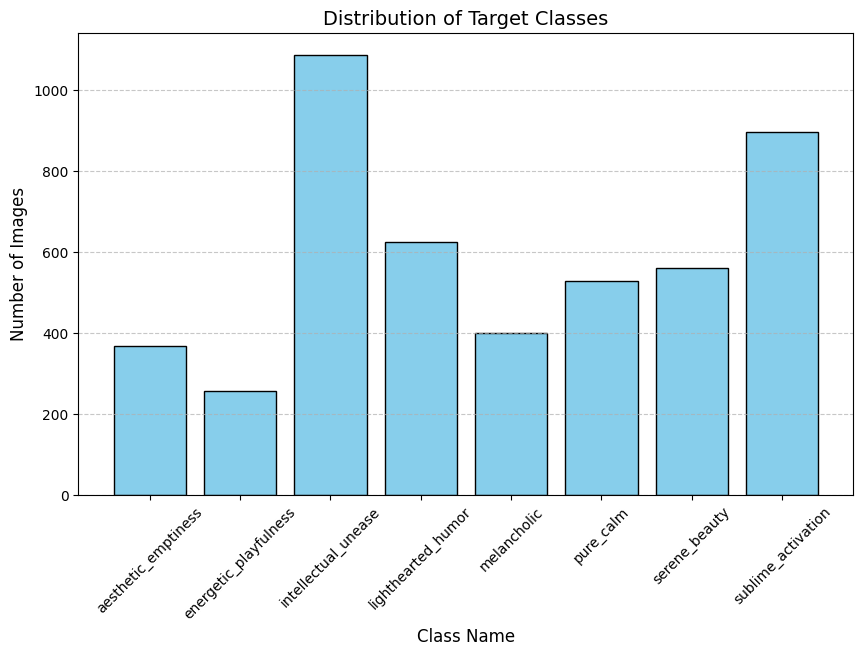

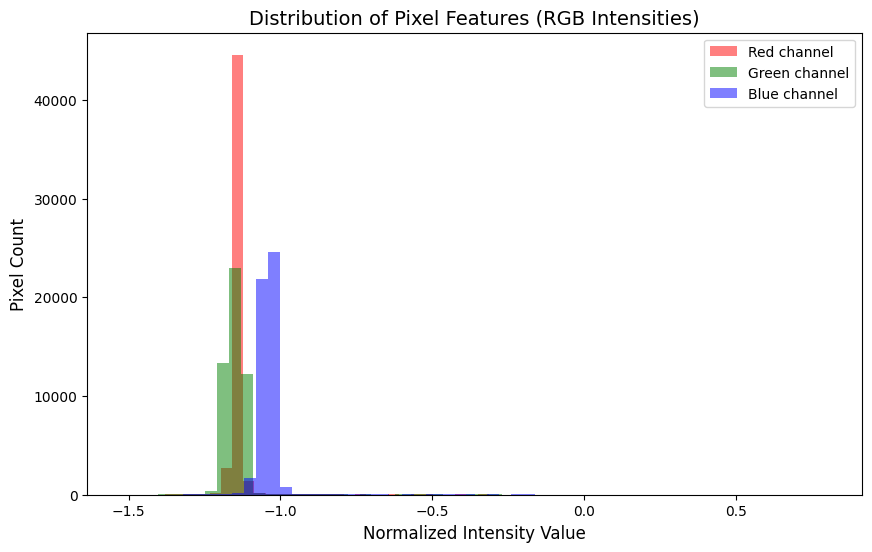

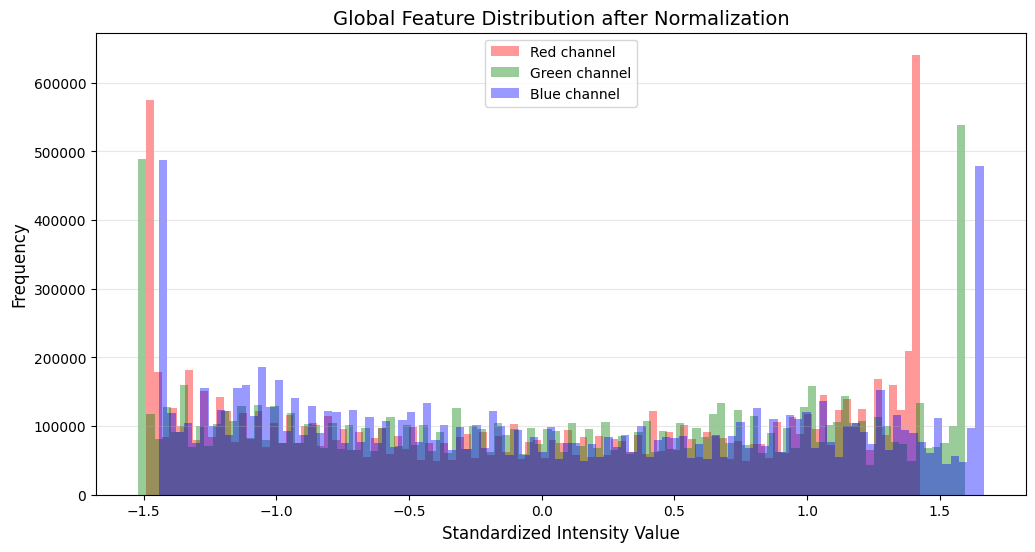

In [26]:
# Example: Plotting histograms of all numerical features
#df.hist(figsize=(12, 12))
#plt.show()


import matplotlib.pyplot as plt
from collections import Counter

# Get class names and counts
class_names = my_dataset_train.classes
label_counts = Counter([label for _, label in my_dataset_train.imgs])
counts = [label_counts[i] for i in range(len(class_names))]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts, color='skyblue', edgecolor='black')
plt.title("Distribution of Target Classes", fontsize=14)
plt.xlabel("Class Name", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



# Extract one image from the dataset
img, _ = my_dataset_train[100] # Using index 100 as in your previous check
img_np = img.numpy()

plt.figure(figsize=(10, 6))
colors = ('red', 'green', 'blue')
for i, color in enumerate(colors):
    # .ravel() flattens the 2D image channel into a 1D array for the histogram
    plt.hist(img_np[i].ravel(), bins=56, color=color, alpha=0.5, label=f'{color.title()} channel')

plt.title("Distribution of Pixel Features (RGB Intensities)", fontsize=14)
plt.xlabel("Normalized Intensity Value", fontsize=12)
plt.ylabel("Pixel Count", fontsize=12)
plt.legend()
plt.show()


#fo 100 pics

import torch
from torch.utils.data import Subset

# 1. Sample 100-200 images to get a representative distribution without using too much RAM
indices = np.random.choice(len(my_dataset_train), size=min(200, len(my_dataset_train)), replace=False)
subset = Subset(my_dataset_train, indices)

red_pixels, green_pixels, blue_pixels = [], [], []

for img, _ in subset:
    # img is [C, H, W], we flatten each channel
    red_pixels.append(img[0].ravel().numpy())
    green_pixels.append(img[1].ravel().numpy())
    blue_pixels.append(img[2].ravel().numpy())

# Flatten the lists into single arrays
red_pixels = np.concatenate(red_pixels)
green_pixels = np.concatenate(green_pixels)
blue_pixels = np.concatenate(blue_pixels)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.hist(red_pixels, bins=100, color='red', alpha=0.4, label='Red channel')
plt.hist(green_pixels, bins=100, color='green', alpha=0.4, label='Green channel')
plt.hist(blue_pixels, bins=100, color='blue', alpha=0.4, label='Blue channel')

plt.title("Global Feature Distribution after Normalization", fontsize=14)
plt.xlabel("Standardized Intensity Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]







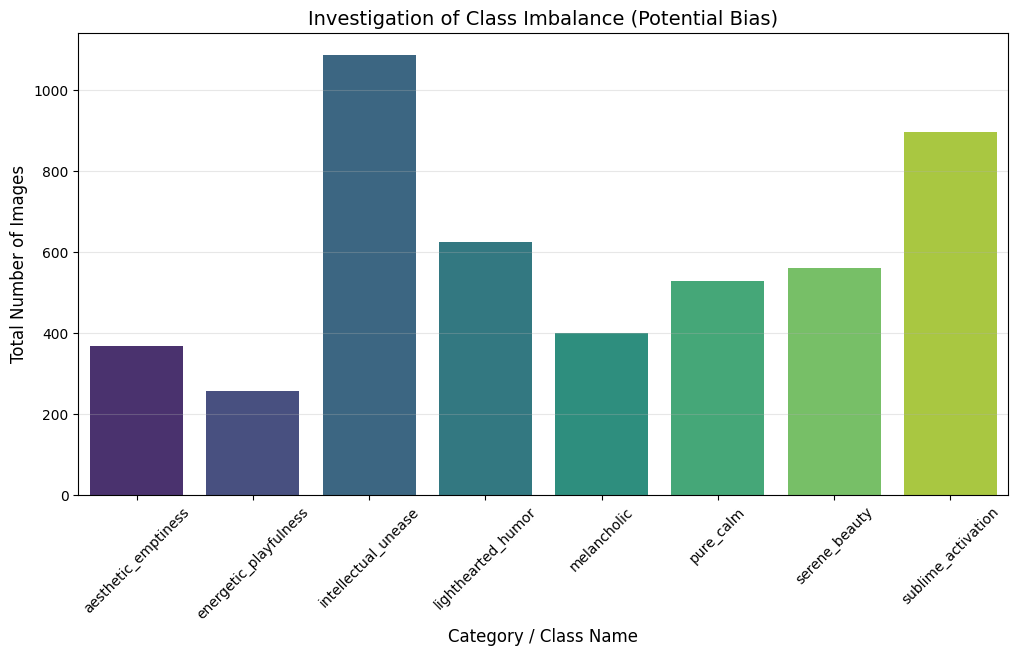

Imbalance Ratio (Max/Min): 4.25


In [25]:
# Example: Checking for class imbalance in a classification problem
# sns.countplot(x='target_variable', data=df)

# Your code to investigate possible biases goes here

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Extract labels and map them to class names
labels = [label for _, label in my_dataset_train.imgs]
class_names = my_dataset_train.classes
label_names = [class_names[l] for l in labels]

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(x=label_names, palette='viridis', hue=label_names, legend=False)

plt.title('Investigation of Class Imbalance (Potential Bias)', fontsize=14)
plt.xlabel('Category / Class Name', fontsize=12)
plt.ylabel('Total Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Calculate the imbalance ratio
counts = Counter(labels).values()
imbalance_ratio = max(counts) / min(counts)
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")



## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


In [ ]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
